<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/Python-Notebook-Banners/Examples.png"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [2]:
dataset = pd.read_csv("https://raw.githubusercontent.com/Kalungup/Income-Based-Purchase-Prediction-Model/refs/heads/main/customer_spending_dataset.csv")
dataset

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,gender,city,education,date,purchase_amount
0,1,56,25287,18,31314,167,80,Female,New York,PhD,2023-01-01,2519
1,2,46,54387,40,3643,152,109,Female,Stockholm,Master,2023-01-02,22915
2,3,32,28512,21,41785,177,83,Male,London,Bachelor,2023-01-03,19997
3,4,60,21342,15,19681,155,105,Male,Stockholm,Master,2023-01-04,10001
4,5,25,83076,97,39328,193,64,Male,Nairobi,Master,2023-01-05,36005
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,22,37778,70,19156,192,84,Male,Stockholm,High School,2025-09-22,12338
996,997,40,65241,44,21360,151,81,Male,London,High School,2025-09-23,32896
997,998,27,62229,73,19135,198,107,Female,London,Bachelor,2025-09-24,26035
998,999,61,106652,45,26351,158,97,Male,London,PhD,2025-09-25,35371


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      1000 non-null   int64 
 1   age              1000 non-null   int64 
 2   income           1000 non-null   int64 
 3   spending_score   1000 non-null   int64 
 4   savings          1000 non-null   int64 
 5   height_cm        1000 non-null   int64 
 6   weight_kg        1000 non-null   int64 
 7   gender           1000 non-null   object
 8   city             1000 non-null   object
 9   education        1000 non-null   object
 10  date             1000 non-null   object
 11  purchase_amount  1000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 93.9+ KB


In [4]:
dataset.describe()

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,500.500000,40.986000,69404.683000,48.108000,24048.647000,174.7780,80.217000,25517.706000
std,288.819436,13.497852,28581.018123,28.981861,14031.448907,14.7003,17.198014,10101.239778
min,1.000000,18.000000,20060.000000,1.000000,1097.000000,150.0000,50.000000,-2409.000000
25%,250.750000,29.000000,45519.000000,22.000000,11997.250000,162.0000,66.000000,18112.750000
50%,500.500000,42.000000,68816.000000,46.500000,23053.000000,175.0000,80.000000,25978.500000
75%,750.250000,52.000000,94672.250000,73.000000,35613.000000,188.0000,95.000000,33130.000000
max,1000.000000,64.000000,119986.000000,99.000000,49980.000000,199.0000,109.000000,55215.000000


#### Notes there are negative earnings, Which is not realistic, so we use absolute values instead.

In [5]:
dataset['purchase_amount'] = abs(dataset['purchase_amount'])
dataset.describe()

,customer_id,age,income,spending_score,savings,height_cm,weight_kg,purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,500.500000,40.986000,69404.683000,48.108000,24048.647000,174.7780,80.217000,25524.640000
std,288.819436,13.497852,28581.018123,28.981861,14031.448907,14.7003,17.198014,10083.687973
min,1.000000,18.000000,20060.000000,1.000000,1097.000000,150.0000,50.000000,840.000000
25%,250.750000,29.000000,45519.000000,22.000000,11997.250000,162.0000,66.000000,18112.750000
50%,500.500000,42.000000,68816.000000,46.500000,23053.000000,175.0000,80.000000,25978.500000
75%,750.250000,52.000000,94672.250000,73.000000,35613.000000,188.0000,95.000000,33130.000000
max,1000.000000,64.000000,119986.000000,99.000000,49980.000000,199.0000,109.000000,55215.000000


Let us consider the age and purchase amount

In [14]:
x = dataset[['age']]
y = dataset['purchase_amount']

<Axes: xlabel='age', ylabel='purchase_amount'>

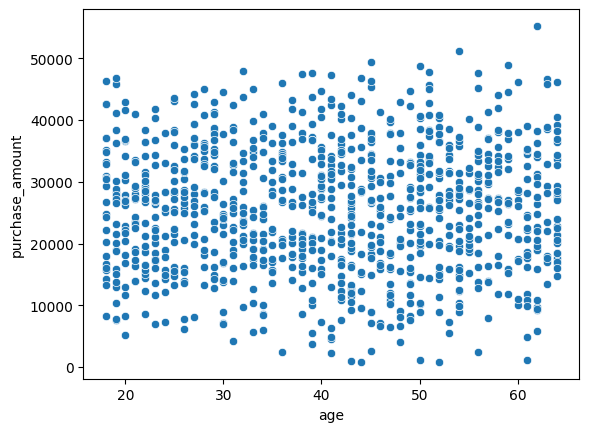

In [16]:
sns.scatterplot(x='age', y='purchase_amount', data=dataset) 

### Linearity Assessment: Age vs Purchase Amount

A scatter plot was used to examine the relationship between age and purchase_amount. The distribution of data points shows a random pattern with no clear linear trend, as the points are widely dispersed across the plot.

There is no evident upward or downward direction, indicating that changes in age do not systematically correspond to changes in purchase_amount. This suggests that the assumption of linearity is not satisfied.

Therefore, age is not an appropriate predictor of purchase_amount in a simple linear regression model, and alternative variables should be considered.

### Linearity Assessment: Income vs Purchase Amount

<Axes: xlabel='income', ylabel='purchase_amount'>

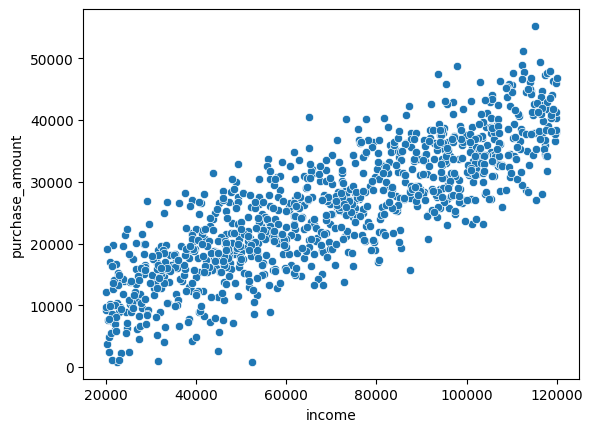

In [18]:
x = dataset['income']
y = dataset['purchase_amount']
sns.scatterplot(x='income', y='purchase_amount', data=dataset)

### Linearity Assessment: Income vs Purchase Amount

A scatter plot indicates a clear positive linear relationship between income and purchase_amount. As income increases, purchase_amount also increases.

Despite some variability, the overall upward trend is consistent, suggesting that the linearity assumption is satisfied. Therefore, income is a suitable predictor for simple linear regression.

#### Now that it meets the linearity assumption, let us check whether there are serious outliers

<Axes: xlabel='purchase_amount'>

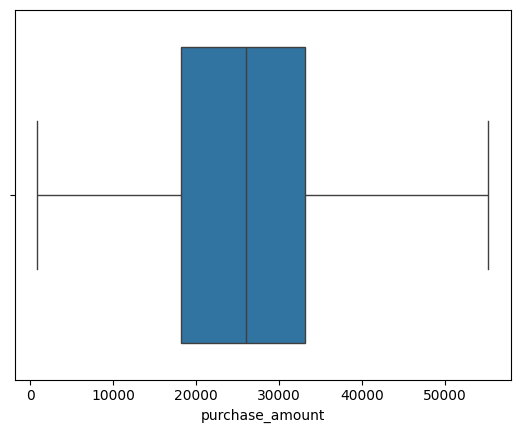

In [19]:
sns.boxplot(x='purchase_amount', data=dataset)



A boxplot was used to assess the presence of outliers in purchase_amount. The distribution appears fairly symmetrical, with no extreme values lying far beyond the whiskers.

Therefore, outliers are unlikely to have a substantial impact on the regression model.

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ImportError: cannot import name 'train_test_spilt' from 'sklearn.model_selection' (c:\Users\Ideapad\.conda\envs\Pythonenvironment\Lib\site-packages\sklearn\model_selection\__init__.py)

from

#### Normlaity of the Residuals